In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA = Path("../../../data/01-anomaly-detection-agent-spec")


def load_pool(name, kind="real"):
    """Load a pool and its metadata by name, e.g. load_pool("R1"), load_pool("S1", "synthetic").

    kind: "real" | "synthetic" | "full"
    """
    base = DATA / kind
    return pd.read_parquet(base / f"{name}.parquet"), pd.read_parquet(base / f"{name}_metadata.parquet")


def pick(meta, n=5, anomalous=None, anomaly_type=None, base_type=None, dataset=None,
         split=None, min_ratio=None, max_ratio=None, sort_by=None, random_state=None):
    """Select series ids from a metadata frame by whatever filters are relevant.

    anomalous     - True/False to keep only dirty/clean series (None = both)
    anomaly_type  - synthetic pools: "point", "group", "flatline", ...
    base_type     - synthetic pools: "ar1", "trend_seasonal", ...
    dataset       - real pools: "YAHOO", "MITDB", ...
    split         - "dev" | "test"
    min_ratio/max_ratio - bounds on the share of anomalous points in the series
    sort_by       - metadata column to sort by, e.g. "anomaly_ratio" for the densest
    random_state  - int for a reproducible random pick instead of the first n
    """
    df = meta
    ratio_col = "anomaly_ratio" if "anomaly_ratio" in df.columns else "anomaly_fraction"
    if anomalous is not None:
        df = df[df["y_i"] == int(bool(anomalous))]
    if anomaly_type is not None:
        df = df[df["anomaly_type"] == anomaly_type]
    if base_type is not None:
        df = df[df["base_type"] == base_type]
    if dataset is not None:
        df = df[df["series_id"].str.split("__").str[1] == dataset]
    if split is not None:
        df = df[df["split"] == split]
    if min_ratio is not None:
        df = df[df[ratio_col] >= min_ratio]
    if max_ratio is not None:
        df = df[df[ratio_col] <= max_ratio]
    if df.empty:
        print("no series match these filters")
        return []
    if sort_by is not None:
        df = df.sort_values(sort_by, ascending=False)
    elif random_state is not None:
        df = df.sample(min(n, len(df)), random_state=random_state)
    return df["series_id"].head(n).tolist()


def describe(meta_row):
    """Compact tags for a series, tolerant of columns a given pool does not have."""
    if meta_row is None:
        return {}
    keys = ("anomaly_type", "base_type", "severity", "severity_effective", "detect_z",
            "period_detected", "anomaly_ratio", "anomaly_fraction", "split")
    return {k: meta_row[k] for k in keys if k in meta_row and pd.notna(meta_row[k])}


def plot_series(pool, series_id, metadata=None, start=None, end=None, figsize=(14, 4)):
    """Plot one series, marking its labelled anomalous points."""
    series_df = pool[pool["series_id"] == series_id]
    if series_df.empty:
        raise ValueError(f"series {series_id!r} is not in this pool")

    # Metadata is optional: a missing row or column degrades the title, never raises.
    meta_row = None
    if metadata is not None:
        row = metadata[metadata["series_id"] == series_id]
        if not row.empty:
            meta_row = row.iloc[0].to_dict()
    tags = describe(meta_row)

    if start is not None or end is not None:
        series_df = series_df.iloc[start:end]

    x, y = series_df["time_index"], series_df["value"]
    anomalies = series_df["label"] == 1
    title = f"{series_id}\n{len(series_df):,} points | {int(anomalies.sum())} anomalous ({anomalies.mean():.2%})"
    if tags:
        title += " | " + ", ".join(f"{k}={v}" for k, v in tags.items())
    # The same text as the in-image title, but selectable/searchable above the figure.
    print(title.replace("\n", " | "))

    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(x, y, color="steelblue", linewidth=1.0, label="value", zorder=1)
    if anomalies.any():
        ax.scatter(x[anomalies], y[anomalies], color="red", s=12, zorder=2, label="anomaly")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("time_index"); ax.set_ylabel("value")
    ax.legend(); ax.grid(True, alpha=0.3)
    fig.tight_layout(); plt.show(); plt.close(fig)


def show(pool, meta, **kwargs):
    """pick() the matching series and plot each one. Every pick() filter works here."""
    start = kwargs.pop("start", None)
    end = kwargs.pop("end", None)
    figsize = kwargs.pop("figsize", (14, 4))
    for series_id in pick(meta, **kwargs):
        plot_series(pool, series_id, metadata=meta, start=start, end=end, figsize=figsize)


In [2]:
# S1 - stationary pool. Loaded once; every plot below reuses these frames.
s1, s1_meta = load_pool("S1", "synthetic")
print(f"S1: {len(s1_meta)} series, {s1_meta.y_i.mean():.1%} anomalous")
print("anomaly families:", s1_meta.loc[s1_meta.y_i == 1, "anomaly_type"].value_counts().to_dict())
print("base processes:  ", s1_meta.base_type.value_counts().to_dict())


S1: 2000 series, 26.2% anomalous
anomaly families: {'point': 113, 'variance': 113, 'flatline': 108, 'level_shift': 96, 'group': 93}
base processes:   {'ar1': 683, 'ar2': 667, 'white_noise': 650}


In [3]:
# show(s1, s1_meta, n=20, anomaly_type="group")


S1__SYNTH__ar2-00063_full | 3,067 points | 92 anomalous (3.00%) | anomaly_type=flatline, base_type=ar2, severity=2.8555, severity_effective=2.8555, detect_z=9.02, anomaly_fraction=0.029997, split=test


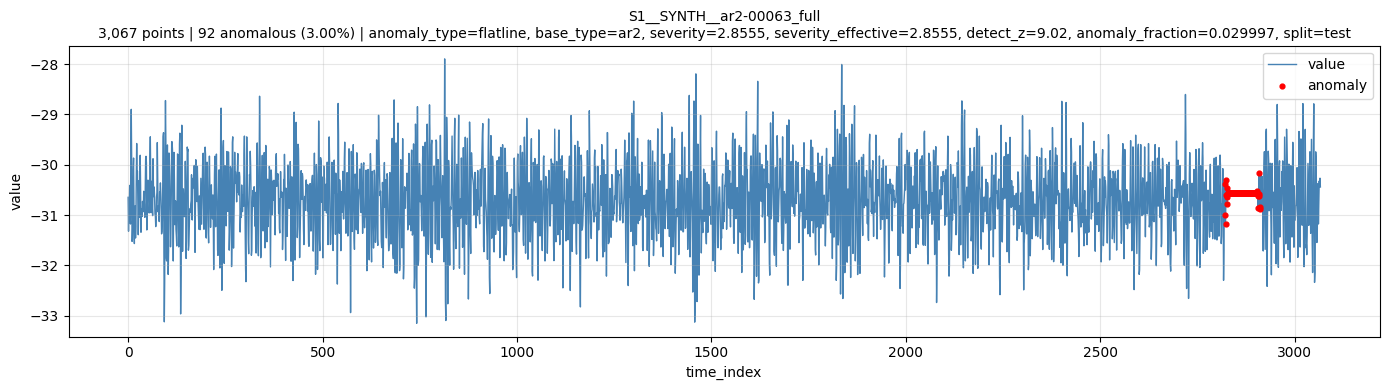

S1__SYNTH__white_noise-00076_full | 1,696 points | 205 anomalous (12.09%) | anomaly_type=flatline, base_type=white_noise, severity=3.1621, severity_effective=3.1621, detect_z=14.1, anomaly_fraction=0.120873, split=dev


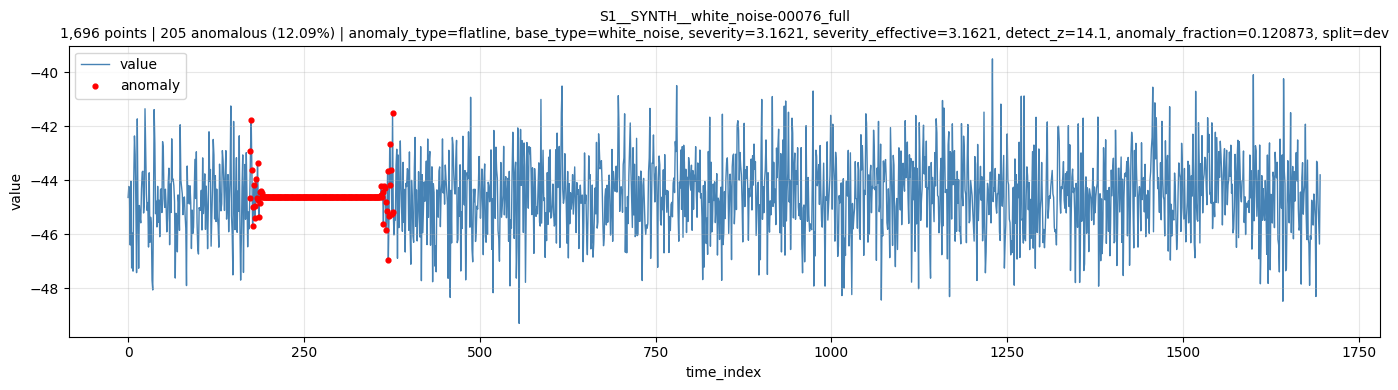

S1__SYNTH__ar1-00084_full | 1,241 points | 22 anomalous (1.77%) | anomaly_type=flatline, base_type=ar1, severity=2.8297, severity_effective=2.8297, detect_z=3.86, anomaly_fraction=0.017728, split=dev


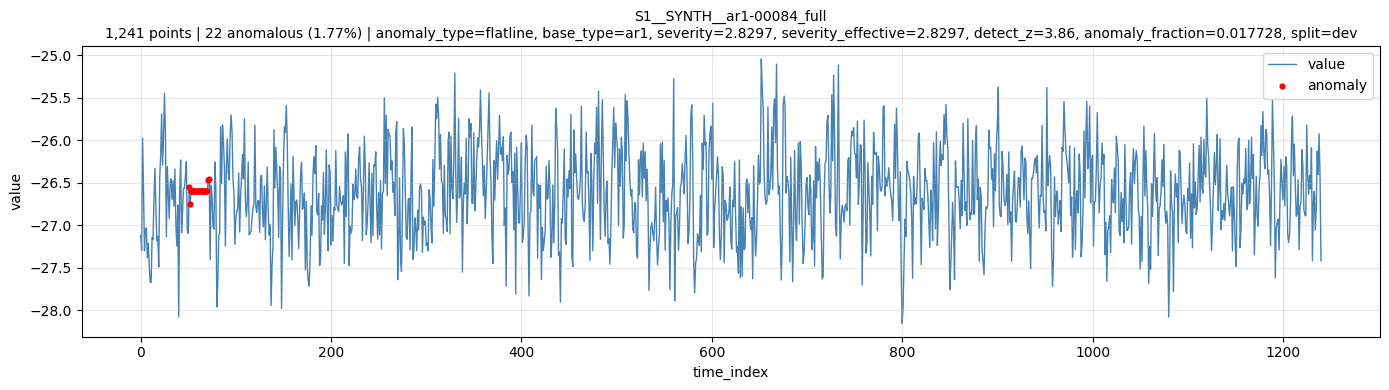

S1__SYNTH__white_noise-00012_full | 1,571 points | 126 anomalous (8.02%) | anomaly_type=group, base_type=white_noise, severity=3.4801, severity_effective=3.4801, detect_z=11.29, anomaly_fraction=0.080204, split=test


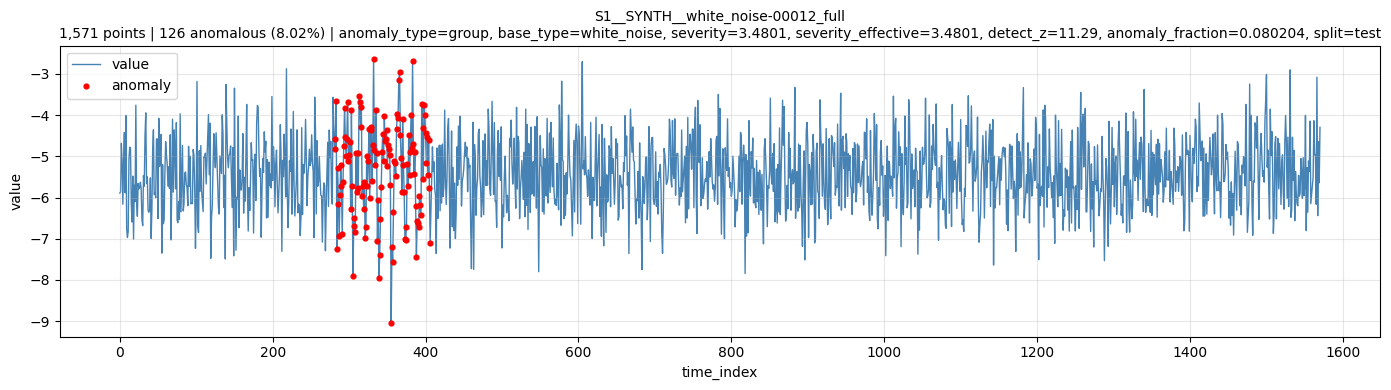

S1__SYNTH__white_noise-00018_full | 3,793 points | 126 anomalous (3.32%) | anomaly_type=group, base_type=white_noise, severity=3.1276, severity_effective=3.1276, detect_z=16.58, anomaly_fraction=0.033219, split=test


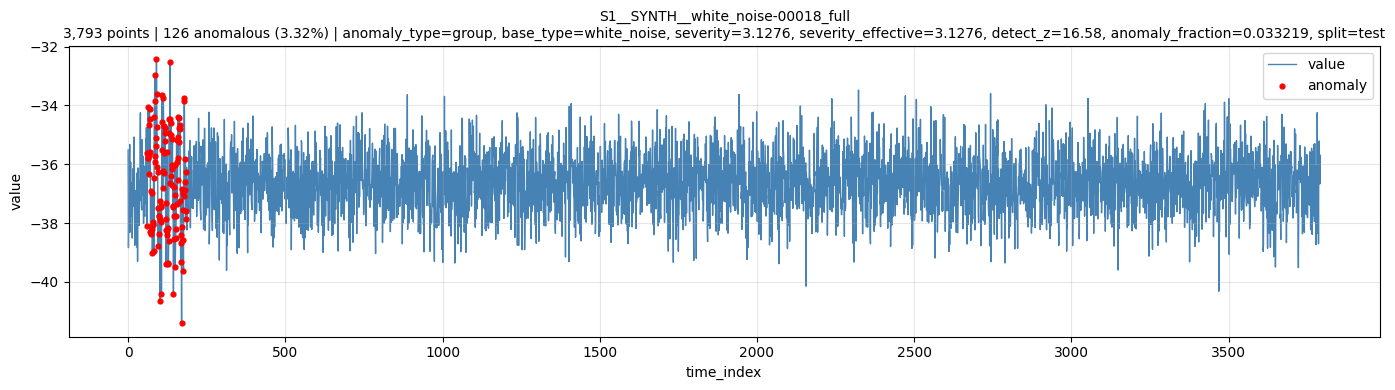

S1__SYNTH__ar2-00124_full | 3,423 points | 586 anomalous (17.12%) | anomaly_type=group, base_type=ar2, severity=2.8355, severity_effective=2.913, detect_z=94.96, anomaly_fraction=0.171195, split=test


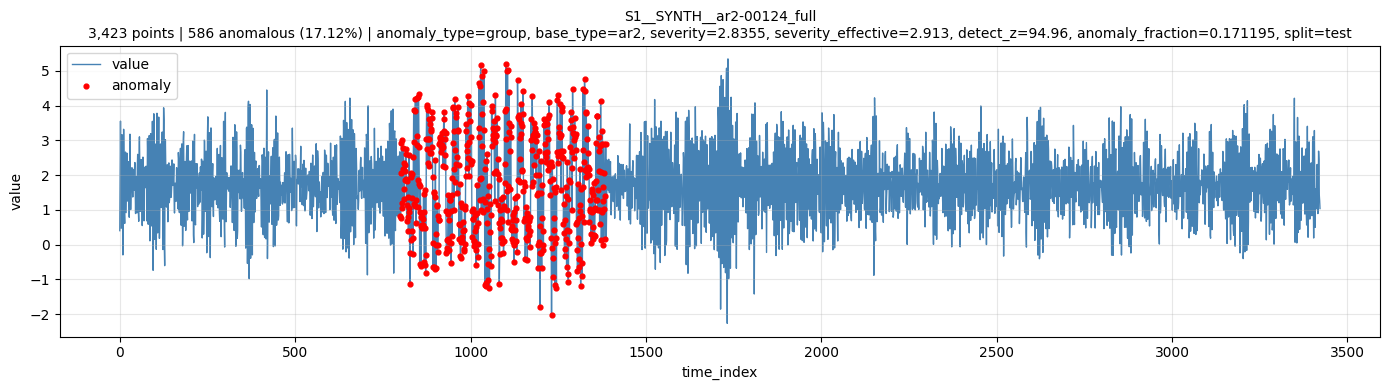

S1__SYNTH__ar1-00071_full | 3,997 points | 138 anomalous (3.45%) | anomaly_type=level_shift, base_type=ar1, severity=3.2972, severity_effective=3.2972, detect_z=26.37, anomaly_fraction=0.034526, split=test


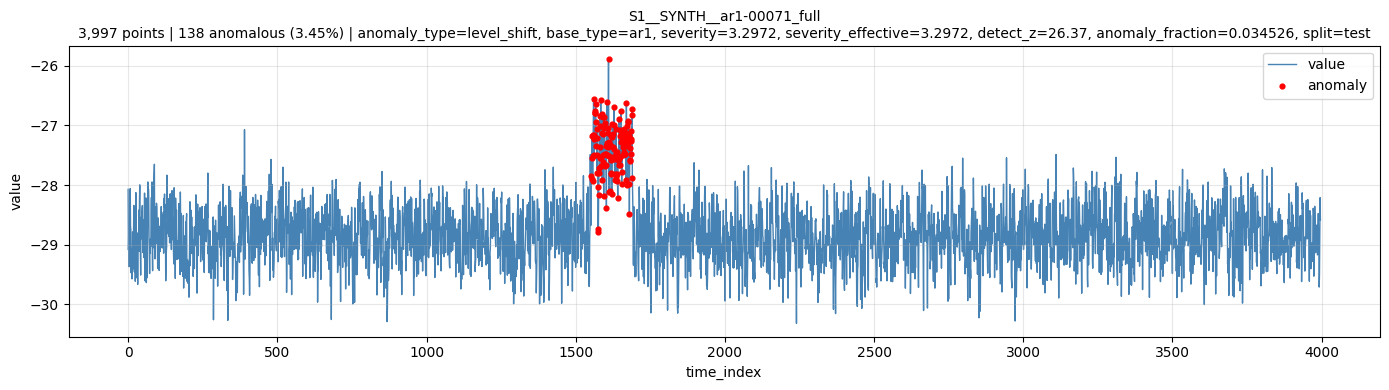

S1__SYNTH__ar2-00090_full | 3,685 points | 147 anomalous (3.99%) | anomaly_type=level_shift, base_type=ar2, severity=3.2905, severity_effective=3.2905, detect_z=46.07, anomaly_fraction=0.039891, split=dev


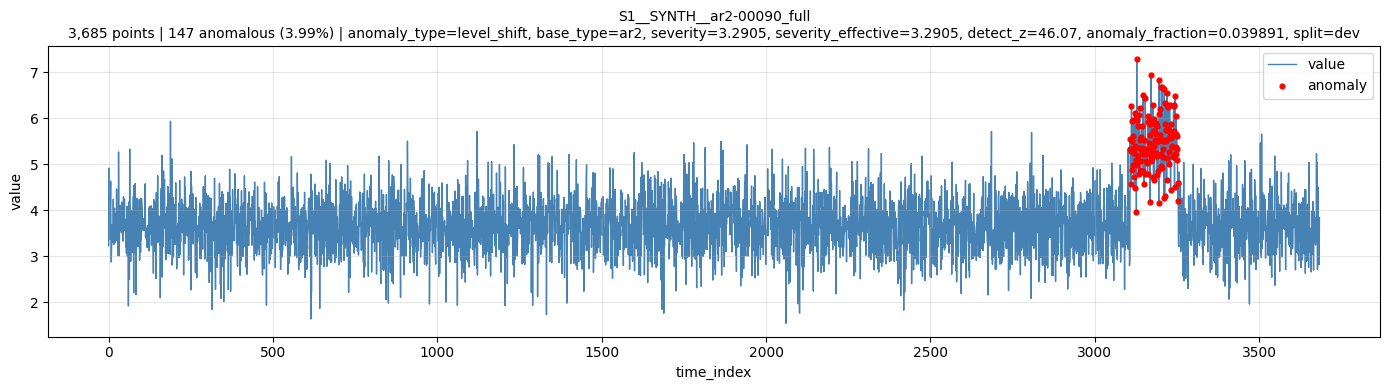

S1__SYNTH__ar1-00100_full | 3,106 points | 41 anomalous (1.32%) | anomaly_type=level_shift, base_type=ar1, severity=3.2324, severity_effective=3.2324, detect_z=30.05, anomaly_fraction=0.0132, split=dev


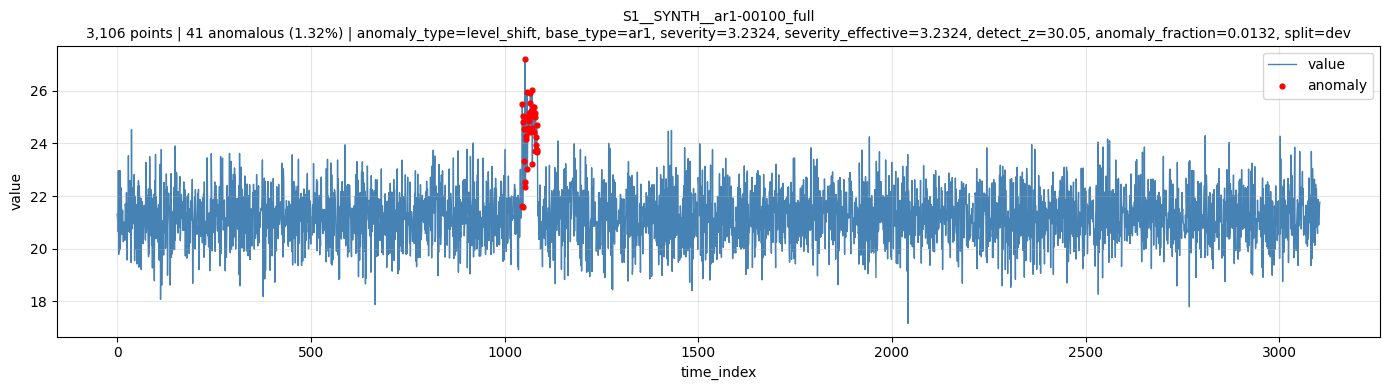

S1__SYNTH__ar1-00000_full | 3,131 points | 63 anomalous (2.01%) | anomaly_type=point, base_type=ar1, severity=2.9306, severity_effective=3.4201, detect_z=59.56, anomaly_fraction=0.020121, split=test


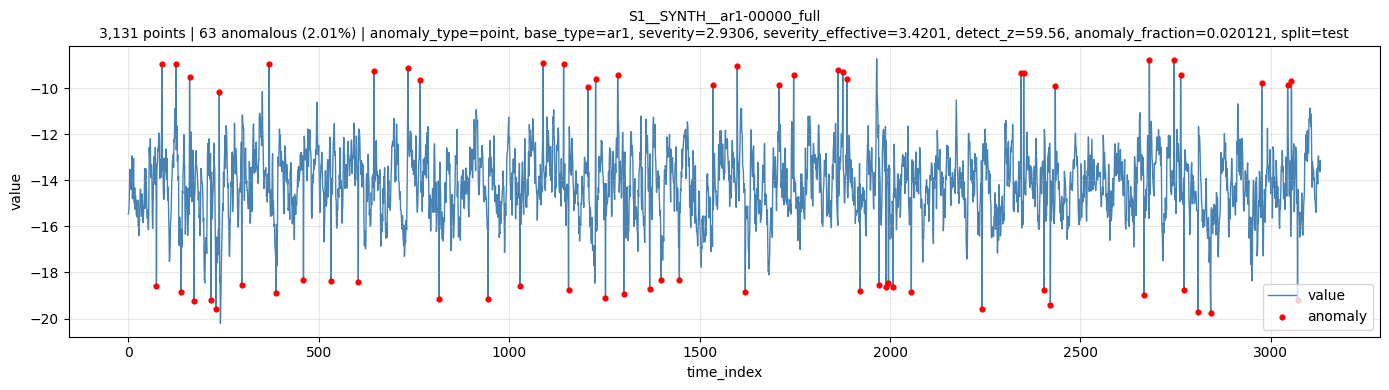

S1__SYNTH__ar1-00007_full | 1,400 points | 11 anomalous (0.79%) | anomaly_type=point, base_type=ar1, severity=2.6943, severity_effective=3.3931, detect_z=18.6, anomaly_fraction=0.007857, split=test


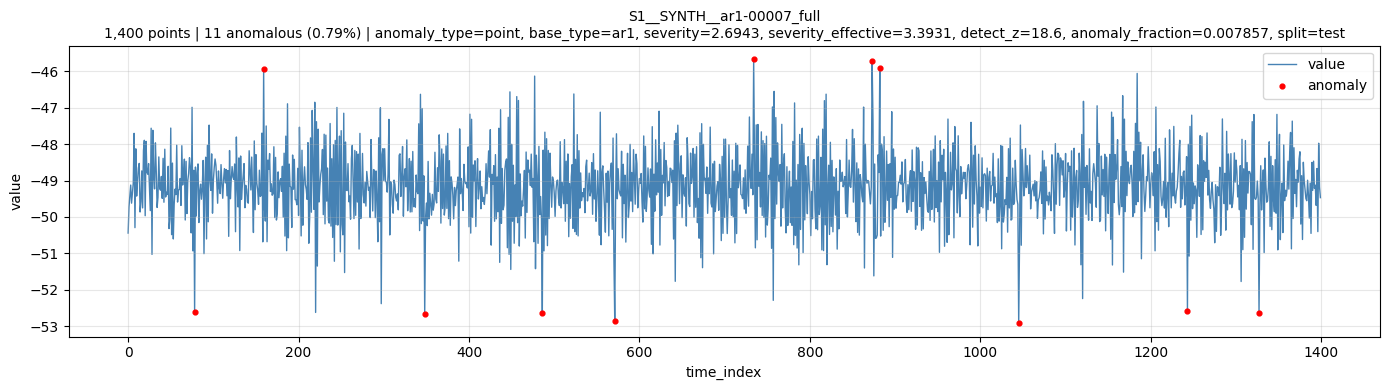

S1__SYNTH__ar1-00034_full | 2,083 points | 32 anomalous (1.54%) | anomaly_type=point, base_type=ar1, severity=3.0915, severity_effective=3.8883, detect_z=55.73, anomaly_fraction=0.015362, split=dev


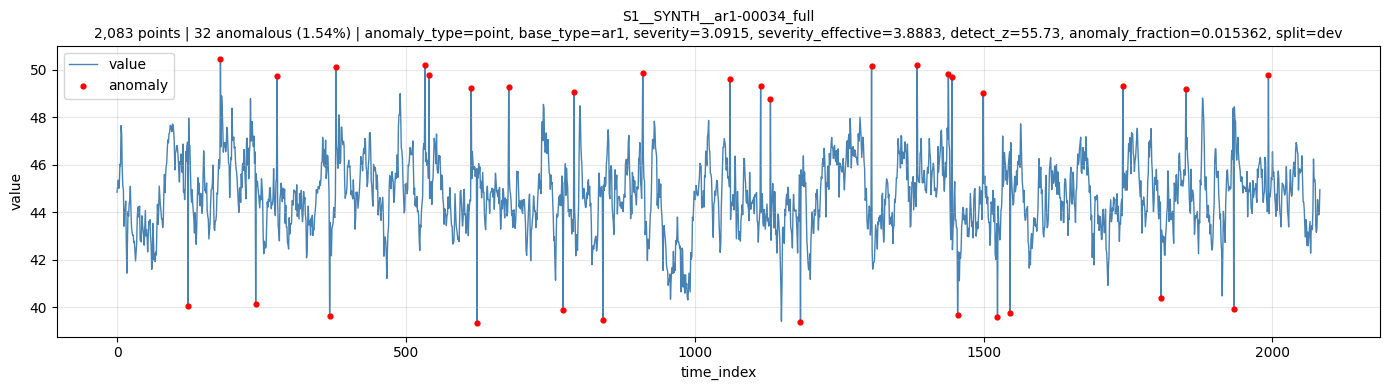

S1__SYNTH__white_noise-00021_full | 3,781 points | 105 anomalous (2.78%) | anomaly_type=variance, base_type=white_noise, severity=2.6683, severity_effective=2.6683, detect_z=5.64, anomaly_fraction=0.02777, split=dev


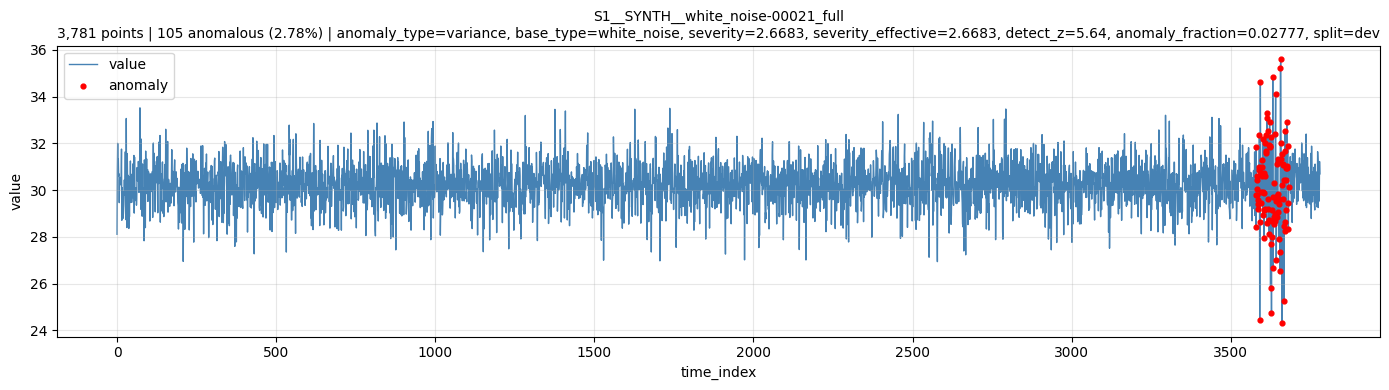

S1__SYNTH__ar1-00056_full | 3,162 points | 62 anomalous (1.96%) | anomaly_type=variance, base_type=ar1, severity=2.8078, severity_effective=3.3133, detect_z=5.0, anomaly_fraction=0.019608, split=test


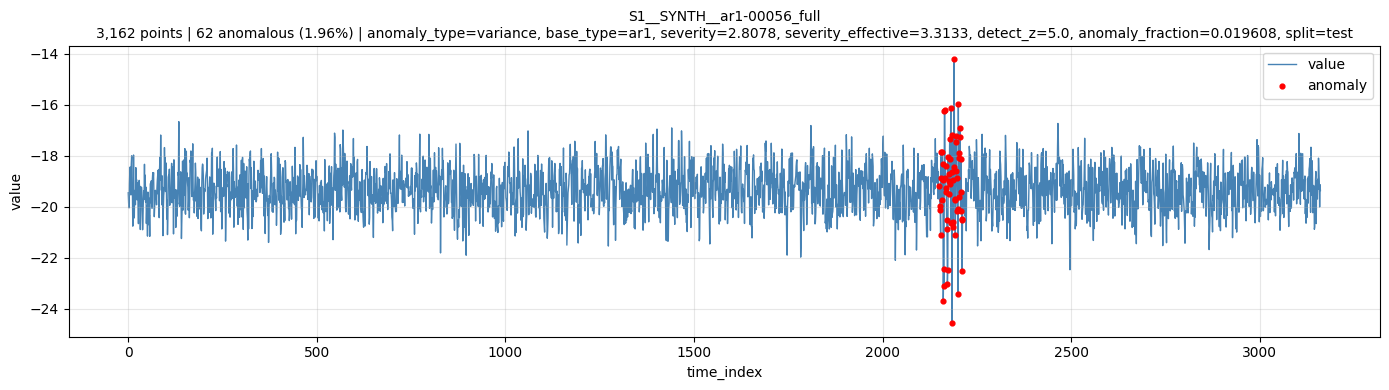

S1__SYNTH__ar1-00078_full | 2,513 points | 70 anomalous (2.79%) | anomaly_type=variance, base_type=ar1, severity=3.4402, severity_effective=3.4402, detect_z=5.44, anomaly_fraction=0.027855, split=test


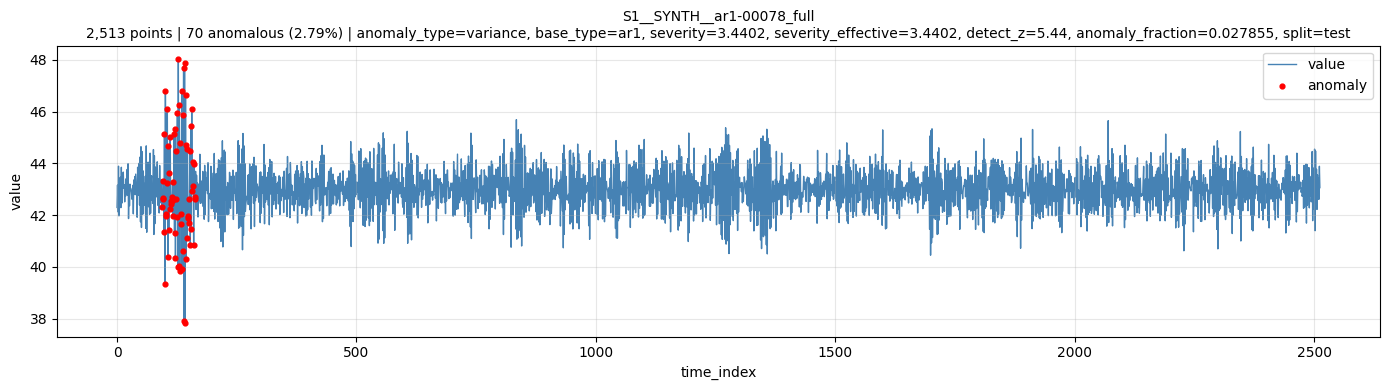

In [4]:
# One example of every anomaly family - the quickest way to see what each looks like.
for family in sorted(s1_meta.loc[s1_meta.y_i == 1, "anomaly_type"].unique()):
    show(s1, s1_meta, n=3, anomaly_type=family)


In [5]:
# S2 - trend-seasonal pool, same tour.
s2, s2_meta = load_pool("S2", "synthetic")
print(f"S2: {len(s2_meta)} series, {s2_meta.y_i.mean():.1%} anomalous")
print("anomaly families:", s2_meta.loc[s2_meta.y_i == 1, "anomaly_type"].value_counts().to_dict())
print("base processes:  ", s2_meta.base_type.value_counts().to_dict())

S2: 2000 series, 24.2% anomalous
anomaly families: {'seasonality': 99, 'flatline': 81, 'point': 81, 'group': 77, 'level_shift': 74, 'trend': 72}
base processes:   {'linear_trend': 681, 'trend_seasonal': 674, 'seasonal_sine': 645}


S2__SYNTH__linear_trend-00001_full | 2,749 points | 74 anomalous (2.69%) | anomaly_type=flatline, base_type=linear_trend, severity=3.4662, severity_effective=3.4662, detect_z=7.87, anomaly_fraction=0.026919, split=test


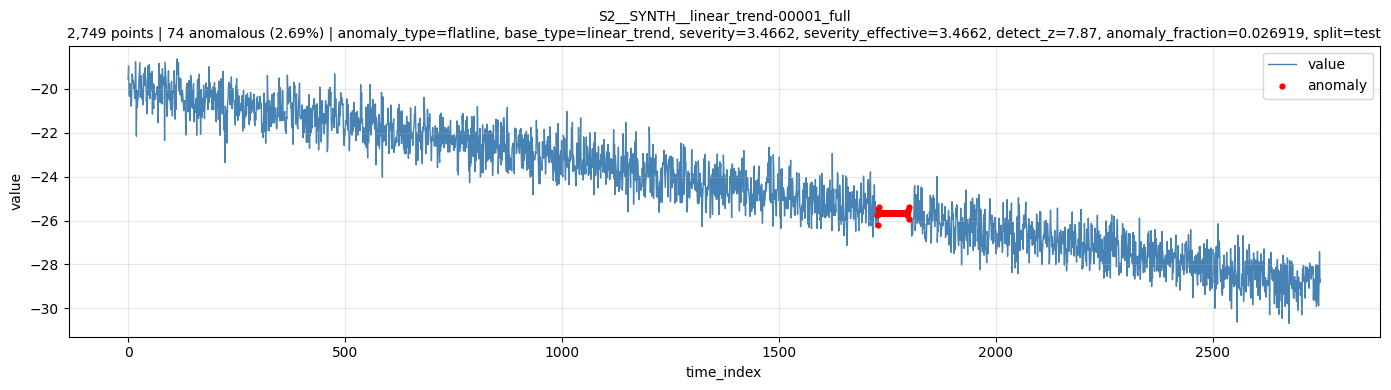

S2__SYNTH__seasonal_sine-00007_full | 1,552 points | 63 anomalous (4.06%) | anomaly_type=flatline, base_type=seasonal_sine, severity=3.5959, severity_effective=3.5959, detect_z=10.23, anomaly_fraction=0.040593, split=test


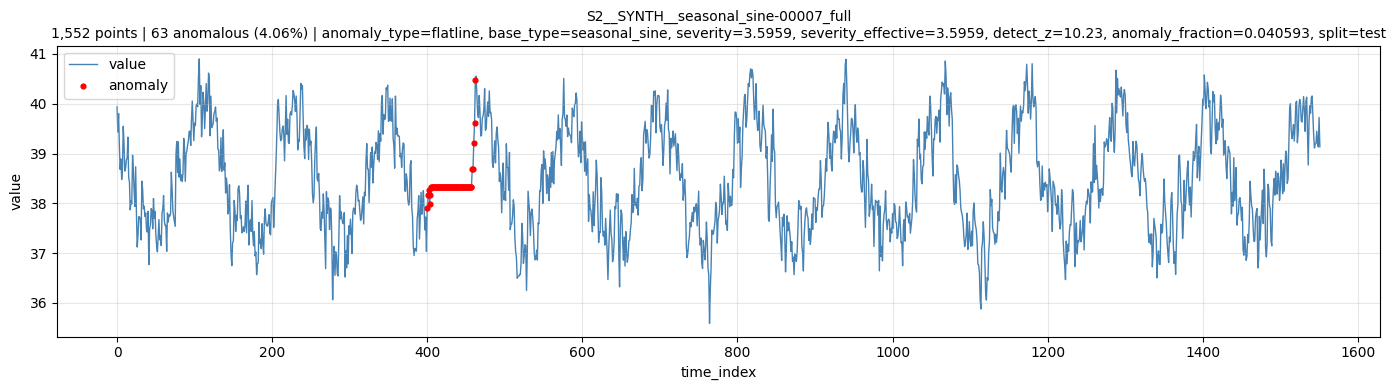

S2__SYNTH__seasonal_sine-00025_full | 3,309 points | 555 anomalous (16.77%) | anomaly_type=flatline, base_type=seasonal_sine, severity=3.5224, severity_effective=3.5224, detect_z=58.65, anomaly_fraction=0.167724, split=test


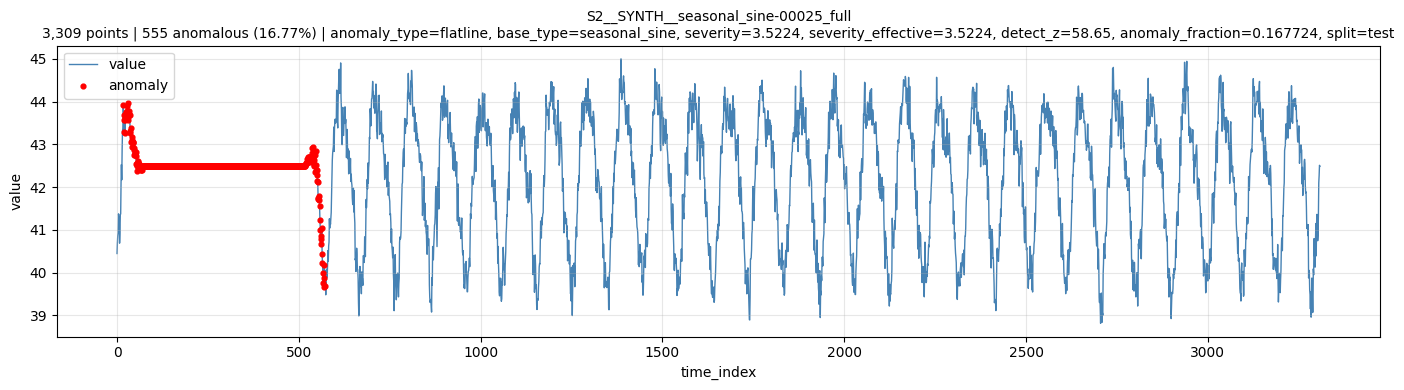

S2__SYNTH__linear_trend-00041_full | 2,816 points | 126 anomalous (4.47%) | anomaly_type=group, base_type=linear_trend, severity=3.5805, severity_effective=3.5805, detect_z=8.05, anomaly_fraction=0.044744, split=test


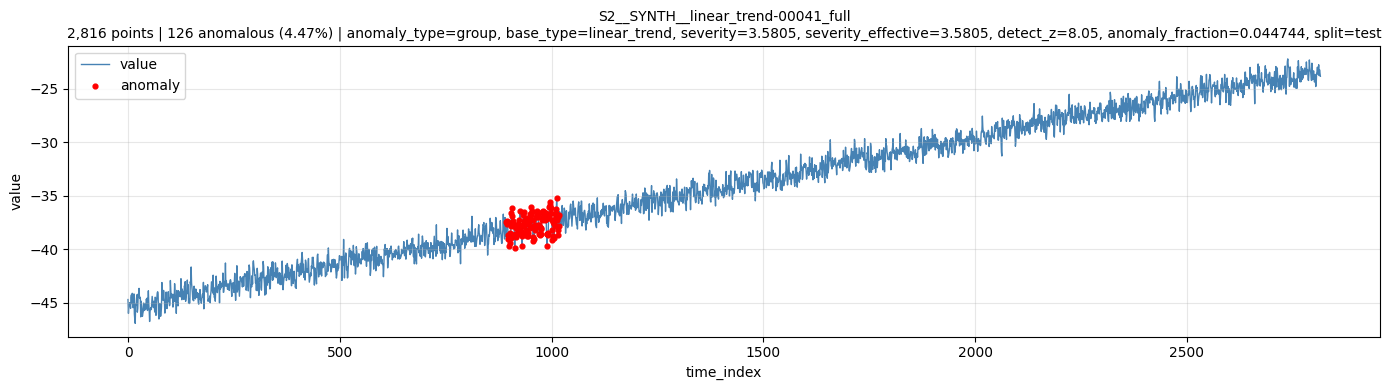

S2__SYNTH__trend_seasonal-00044_full | 2,013 points | 126 anomalous (6.26%) | anomaly_type=group, base_type=trend_seasonal, severity=2.8291, severity_effective=2.8291, detect_z=99.94, anomaly_fraction=0.062593, split=dev


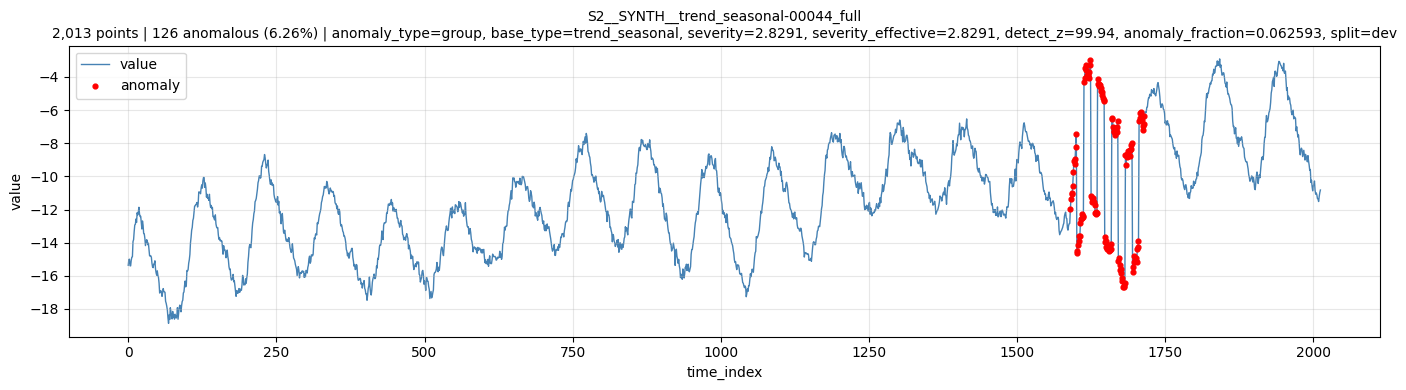

S2__SYNTH__seasonal_sine-00063_full | 2,918 points | 162 anomalous (5.55%) | anomaly_type=group, base_type=seasonal_sine, severity=3.2008, severity_effective=3.153, detect_z=58.2, anomaly_fraction=0.055517, split=test


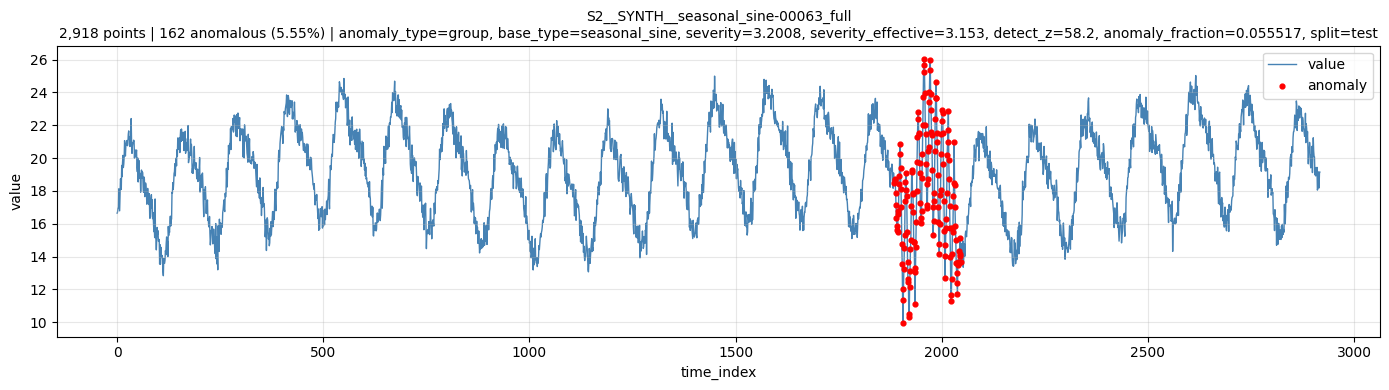

S2__SYNTH__trend_seasonal-00042_full | 1,576 points | 384 anomalous (24.37%) | anomaly_type=level_shift, base_type=trend_seasonal, severity=2.7491, severity_effective=2.7491, detect_z=74.55, anomaly_fraction=0.243655, split=test


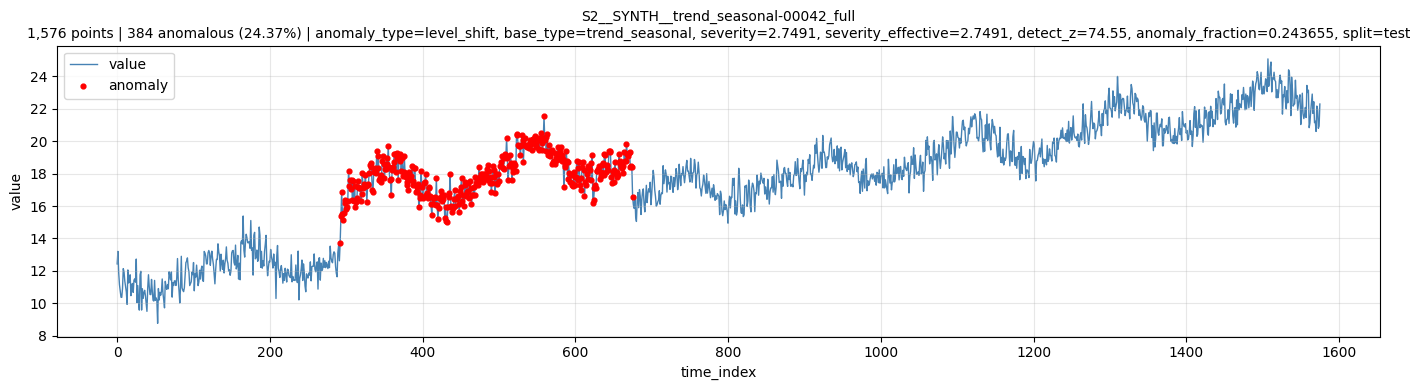

S2__SYNTH__trend_seasonal-00056_full | 2,530 points | 348 anomalous (13.75%) | anomaly_type=level_shift, base_type=trend_seasonal, severity=2.7313, severity_effective=2.7313, detect_z=56.84, anomaly_fraction=0.137549, split=test


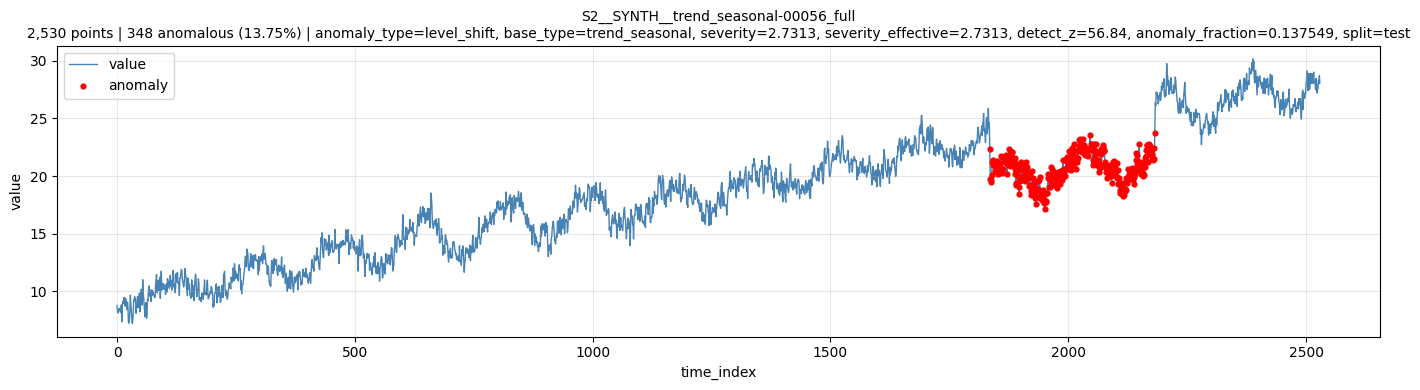

S2__SYNTH__trend_seasonal-00074_full | 3,757 points | 176 anomalous (4.68%) | anomaly_type=level_shift, base_type=trend_seasonal, severity=2.9329, severity_effective=2.6889, detect_z=64.83, anomaly_fraction=0.046846, split=dev


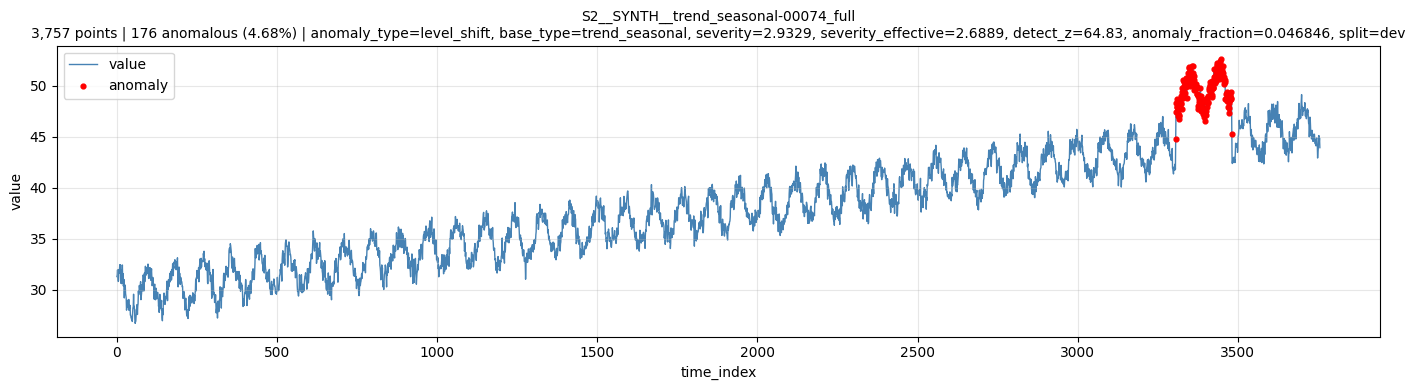

S2__SYNTH__linear_trend-00005_full | 3,956 points | 22 anomalous (0.56%) | anomaly_type=point, base_type=linear_trend, severity=2.667, severity_effective=3.2629, detect_z=19.34, anomaly_fraction=0.005561, split=test


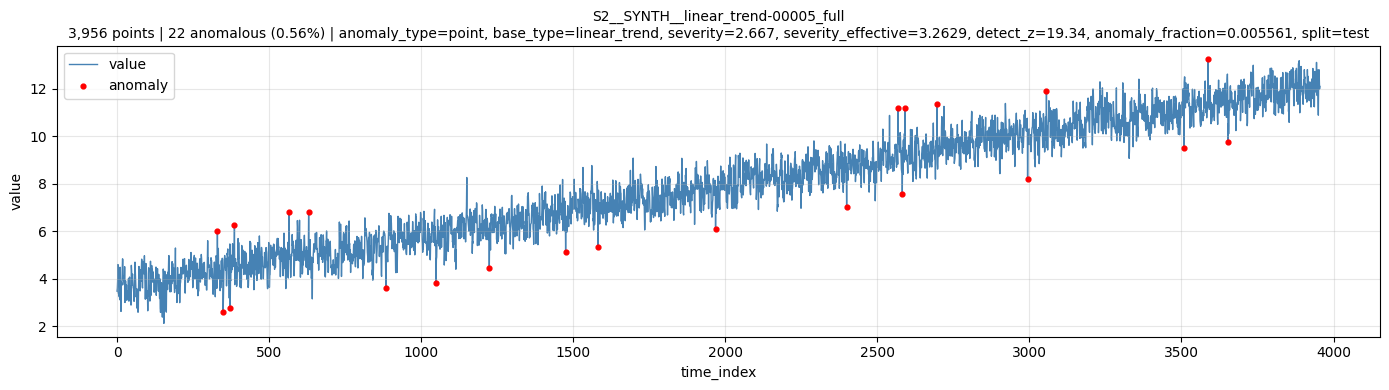

S2__SYNTH__seasonal_sine-00090_full | 2,769 points | 59 anomalous (2.13%) | anomaly_type=point, base_type=seasonal_sine, severity=2.891, severity_effective=2.345, detect_z=69.51, anomaly_fraction=0.021307, split=test


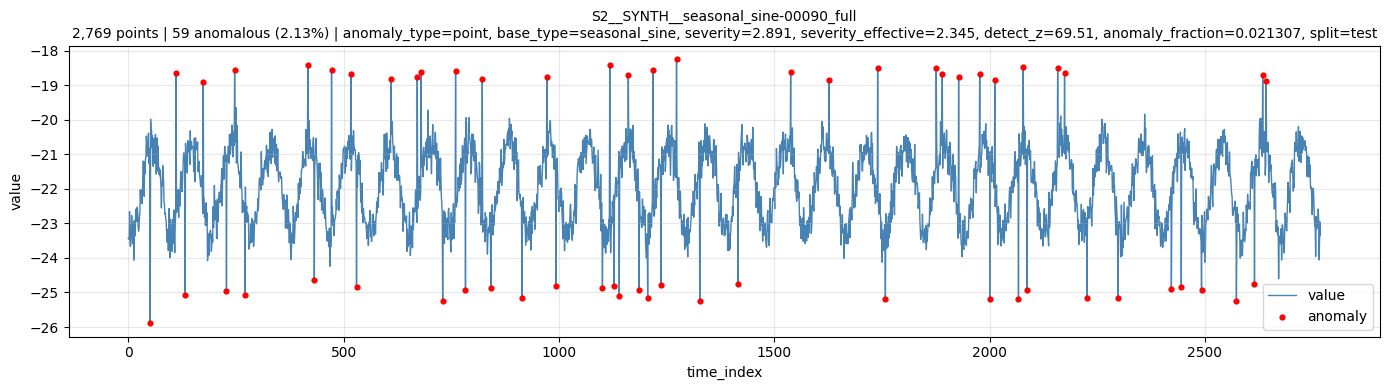

S2__SYNTH__seasonal_sine-00141_full | 2,032 points | 42 anomalous (2.07%) | anomaly_type=point, base_type=seasonal_sine, severity=2.9129, severity_effective=2.1812, detect_z=118.4, anomaly_fraction=0.020669, split=test


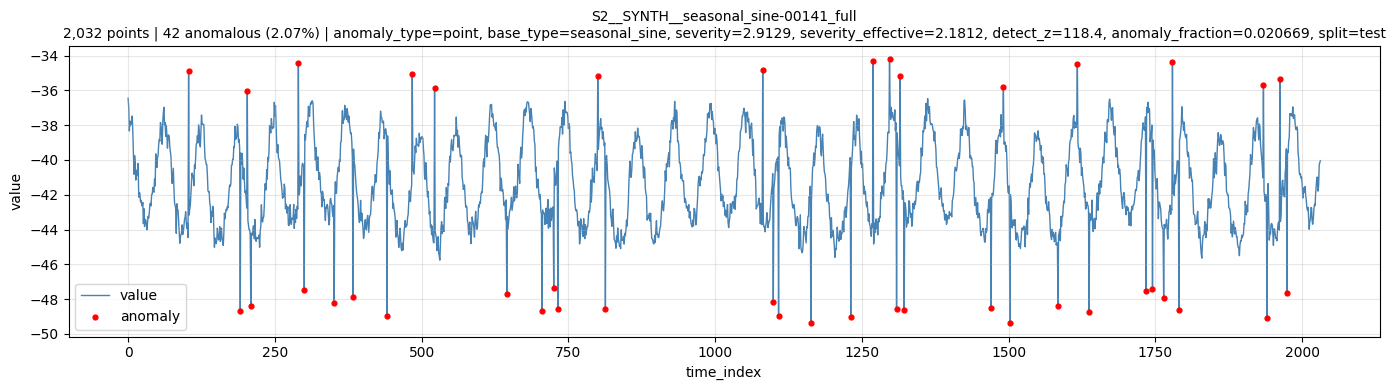

S2__SYNTH__seasonal_sine-00004_full | 3,427 points | 414 anomalous (12.08%) | anomaly_type=seasonality, base_type=seasonal_sine, severity=2.6597, severity_effective=2.6597, detect_z=39.62, anomaly_fraction=0.120805, split=test


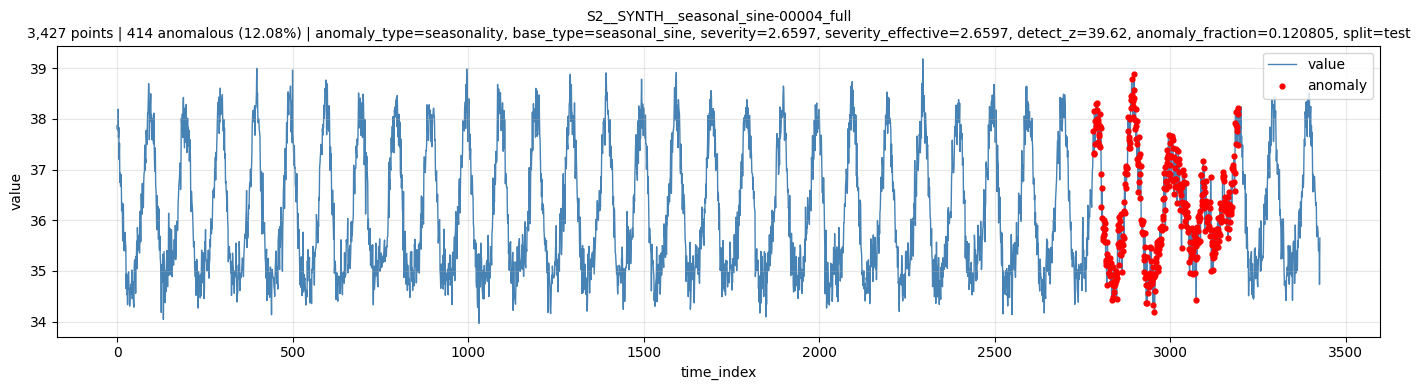

S2__SYNTH__linear_trend-00013_full | 1,446 points | 46 anomalous (3.18%) | anomaly_type=seasonality, base_type=linear_trend, severity=2.9991, severity_effective=4.4378, detect_z=5.0, anomaly_fraction=0.031812, split=test


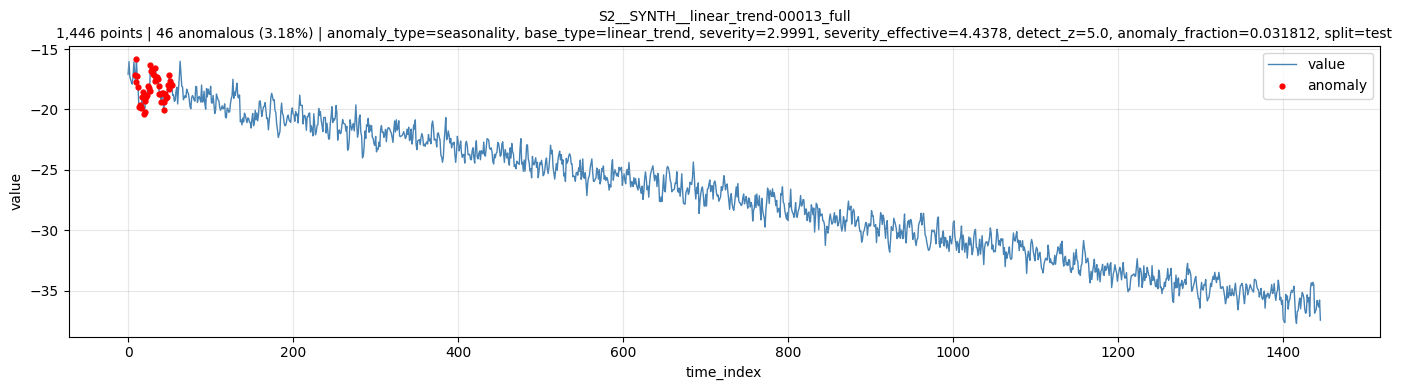

S2__SYNTH__linear_trend-00062_full | 1,945 points | 61 anomalous (3.14%) | anomaly_type=seasonality, base_type=linear_trend, severity=3.2831, severity_effective=3.2831, detect_z=6.2, anomaly_fraction=0.031362, split=test


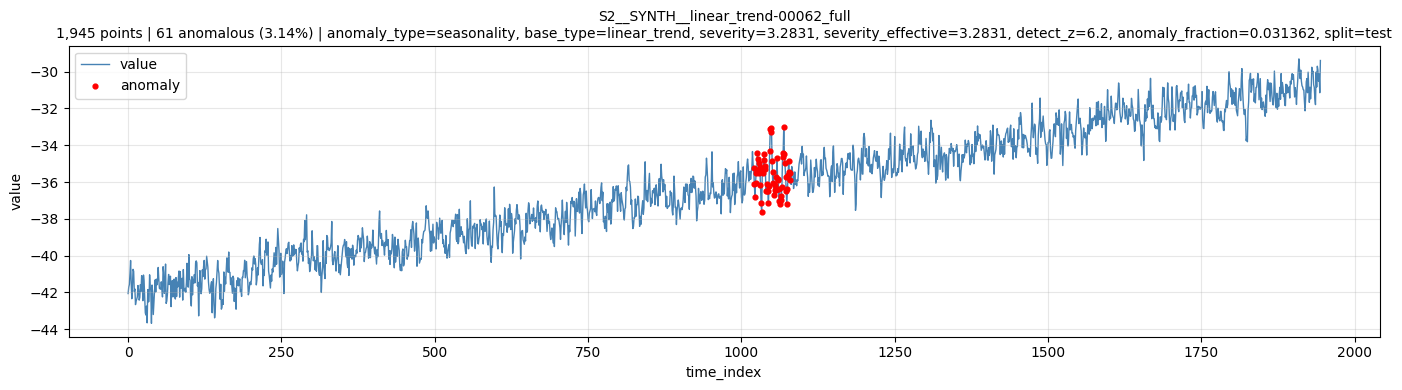

S2__SYNTH__linear_trend-00009_full | 3,869 points | 471 anomalous (12.17%) | anomaly_type=trend, base_type=linear_trend, severity=3.0868, severity_effective=3.0868, detect_z=25.21, anomaly_fraction=0.121737, split=test


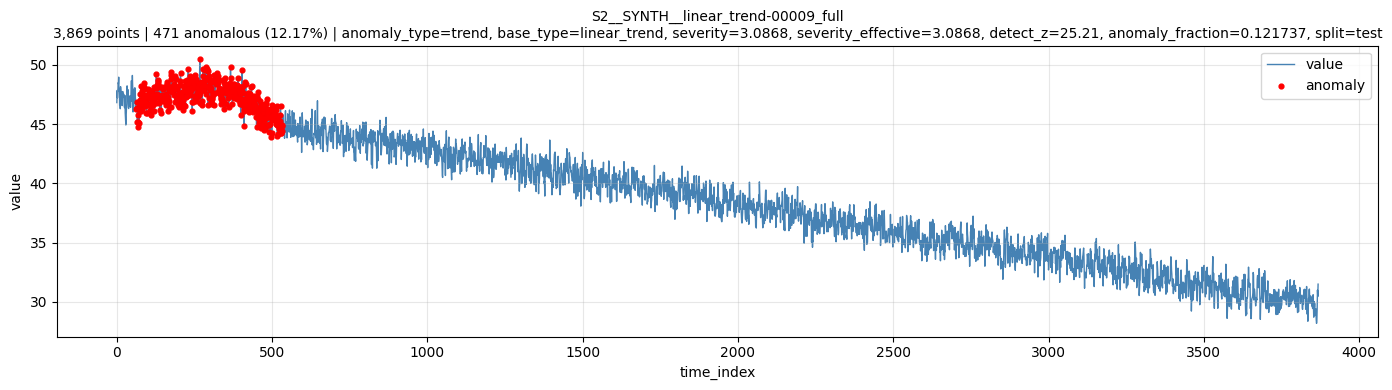

S2__SYNTH__trend_seasonal-00057_full | 3,856 points | 524 anomalous (13.59%) | anomaly_type=trend, base_type=trend_seasonal, severity=2.8863, severity_effective=2.8863, detect_z=60.51, anomaly_fraction=0.135892, split=dev


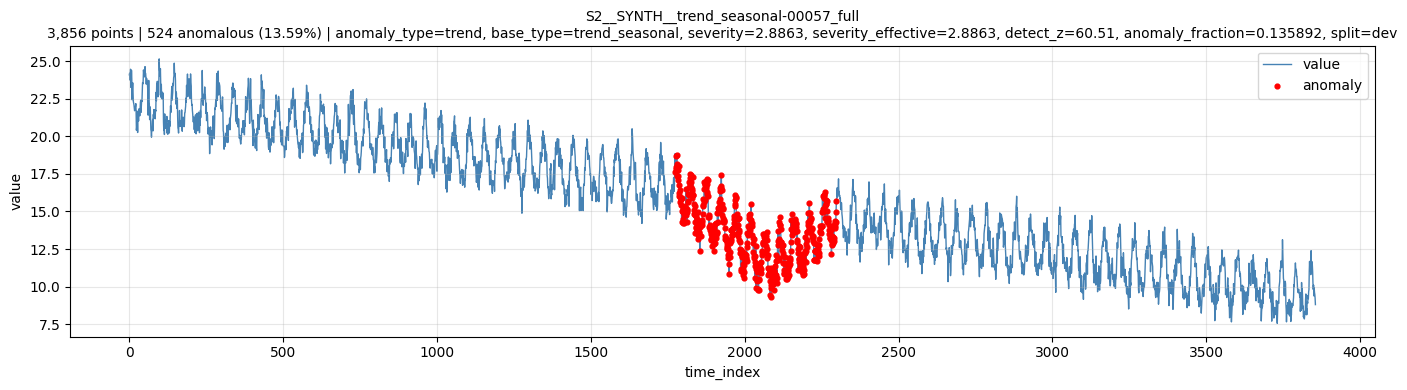

S2__SYNTH__seasonal_sine-00064_full | 2,171 points | 368 anomalous (16.95%) | anomaly_type=trend, base_type=seasonal_sine, severity=2.9888, severity_effective=2.6295, detect_z=87.23, anomaly_fraction=0.169507, split=test


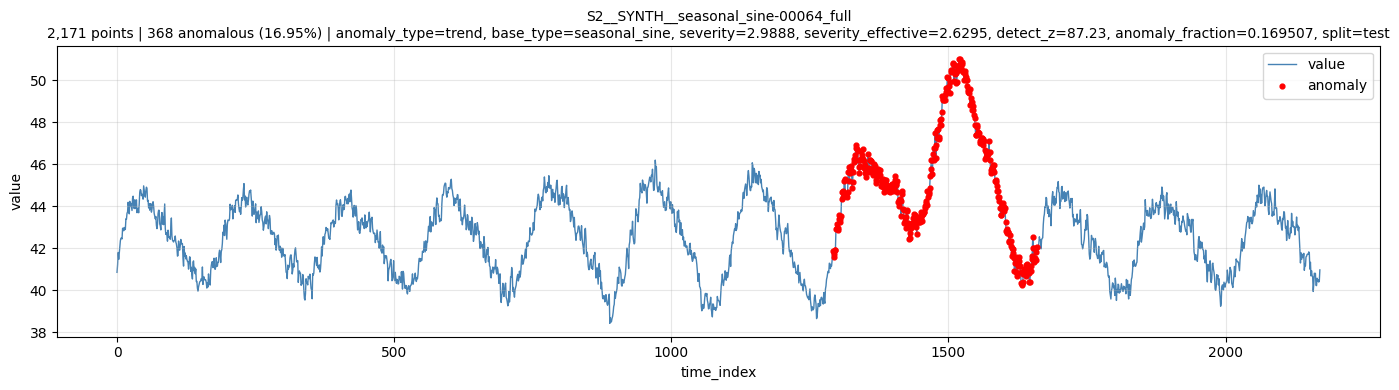

In [6]:
for family in sorted(s2_meta.loc[s2_meta.y_i == 1, "anomaly_type"].unique()):
    show(s2, s2_meta, n=3, anomaly_type=family)

In [7]:
# Free-form exploration. Every filter is optional - mix whichever you need:
#
#   show(s1, s1_meta, n=3, anomaly_type="flatline")          # one family
#   show(s2, s2_meta, n=3, base_type="trend_seasonal")       # one base process
#   show(s1, s1_meta, n=3, anomalous=False)                  # clean series only
#   show(s1, s1_meta, n=3, sort_by="anomaly_fraction")       # densest anomalies first
#   show(s2, s2_meta, n=3, max_ratio=0.01)                   # hardest: sparsest anomalies
#   show(s1, s1_meta, n=3, anomalous=True, random_state=0)   # reproducible random pick
#   show(s1, s1_meta, n=1, anomaly_type="point", start=0, end=500)   # zoom into a window

# show(s1, s1_meta, n=3, anomalous=True, random_state=0)


In [8]:
# show(s1, s1_meta, n=20, anomaly_type="point", sort_by="detect_z")